# Decision Tree

In [3]:
from __future__ import annotations
import copy
from dataclasses import dataclass, field
from collections import Counter
from typing import Any, Dict, List, Optional, Tuple
import numpy as np

## 工具函数

#### 计算经验熵

In [4]:
def entropy_from_counts(counts, base = 2) -> float: # type: ignore
    # counts : 输入频次表 如 [10, 5, 0] 代表类别 A 有 10 个，类别 B 有 5 个，类别 C 有 0 个
    counts = np.asarray(counts, dtype = float)
    counts = counts[counts > 0] # 它过滤掉了数量为 0（或负数）的类别。
    total = counts.sum() # 计算所有剩余类别的样本总数
    if total <= 0:
        return 0
    p = counts / total
    if base == 2:
        return float(-np.sum(p * np.log2(p)))
    elif base == np.e:
        return float(-np.sum(p * np.log(p)))
    else:
        return float(-np.sum(p * np.log(p) / np.log(base))) # 如果没有指明单位，就转换单位为nat

#### 计算Gini指数

In [5]:
def gini_from_counts(counts) -> float:  # type: ignore
    counts = np.asarray(counts, dtype = float)
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts / total
    return float(1.0 - np.sum(p ** 2))

#### 返回出现次数最多的类别

In [6]:
def majority_label(y):
    return Counter(y).most_common(1)[0][0]
# Counter(y).most_common(1)是一个外层为列表，内层为元组的结构 [('apple', 2)]

#### 返回类别计数字典

In [7]:
def counts_dict(y) -> Dict[Any, int]:
    return dict(Counter(y))

#### 检查样本

In [8]:
def check(X, y, dtype = None):
    X = np.asarray(X, dtype = dtype)
    y = np.asarray(y, dtype = dtype)
    if X.ndim != 2:
        raise ValueError("X必须是二维数组")
    if y.ndim != 1:
        y = y.ravel()
    if X.shape[0] != y.shape[0]:
        raise ValueError("X 和 y 的样本数量不一致")
    return X, y

## ID3 / C4.5

#### TreeNode Class
- is_leaf:
    是否为叶节点。
- prediction:
    当前节点的预测类别。
    即使是内部节点，也保存一个多数类预测，用于遇到未知特征值时兜底。
- feature_index:
    当前节点使用哪个特征进行划分。
- children:
    离散特征取值 -> 子节点。

In [9]:
@dataclass
class CategoricalTreeNode:
    is_leaf: bool
    prediction: Any
    depth: int
    n_samples: int # 落入该节点的训练样本总数。
    class_counts: Dict[Any, int] # 落入该节点的样本中，各个类别的数量分布。
    feature_index: Optional[int] = None # 用于分裂数据的最佳特征的索引（在数组或表格中的第几列）。
    feature_name: Optional[str] = None # 用于分裂数据的最佳特征的名称
    criterion_value: float = 0.0 # 当前节点选择最优划分特征时，对应的评价指标值
    children: Dict[Any, "CategoricalTreeNode"] = field(default_factory = dict)

#### 生成算法类

In [10]:
class BaseDecisionTreeClassifier:
    def __init__(self,
                 min_gain: float = 0.0,
                 max_depth: Optional[int] = None,
                 min_samples_split: int = 2,
                 feature_names: Optional[List[str]] = None,
                 use_c45_avg_gain_filter: bool = True,
                 criterion: str = "id3"):
        self.min_gain = min_gain # 最小信息增益阈值,如果当前最优特征的信息增益小于该值，则停止划分。
        self.max_depth = max_depth # 最大树深度。
        self.min_samples_split = min_samples_split # 分裂所需的最小样本数
        self.feature_names = feature_names # 特征名称。
        self.use_c45_avg_gain_filter = use_c45_avg_gain_filter # C4.5中常用的折中策略,先筛选信息增益不低于平均水平的特征，再从中选择信息增益比最大的特征。
        self.root_: Optional[CategoricalTreeNode] = None # 决策树的根节点
        self.classes_ = None # 目标变量（标签）的所有类别
        self.n_features_ = None # 模型训练时接收到的特征总数量
        self.criterion = criterion

    def fit(self, X, y):
        # 默认X是离散特征
        X, y = check(X, y, dtype = object)
        self.classes_ = np.unique(y)
        self.n_features_ = X.shape[1]
        if self.feature_names is None:
            self.feature_names_ = [f"x{j}" for j in range(self.n_features_)]
        else:
            if len(self.feature_names) != self.n_features_:
                raise ValueError("feature_names 的长度必须等于特征数量。")
            self.feature_names_ = list(self.feature_names)
        feature_indices = list(range(self.n_features_)) # 特征序号
        self.root_ = self._build_tree(X, y, feature_indices, depth = 0)
        return self
    # 内部方法
    def _build_tree(self,
                    X: np.ndarray,
                    y: np.ndarray,
                    feature_indices: List[int],
                    depth: int
                    ) -> CategoricalTreeNode:
        node_prediction = majority_label(y)
        node_counts = counts_dict(y)
        node = CategoricalTreeNode(is_leaf = True,
                                   prediction = node_prediction,
                                   depth = depth,
                                   n_samples = len(y),
                                   class_counts = node_counts)
        if len(np.unique(y)) == 1: # 停止条件 1：当前节点全部属于同一类
            return node
        if len(feature_indices) == 0: # 停止条件 2：没有可用特征
            return node
        if self.max_depth is not None and depth >= self.max_depth: # 停止条件 3：达到最大深度
            return node
        if len(y) < self.min_samples_split: # 停止条件 4：样本太少
            return node
        best_feature, best_score, best_gain = self._choose_best_feature( # 选择最优划分特征
            X, y, feature_indices
        )
        if best_feature is None or best_gain < self.min_gain: # # 停止条件 5：信息增益太小
            return node
        # 变成内部节点
        node.is_leaf = False
        node.feature_index = best_feature
        node.feature_name = self.feature_names_[best_feature]
        node.criterion_value = best_score
        remaining_features = [j for j in feature_indices if j != best_feature] # 排除掉使用过的特征
        values = np.unique(X[:, best_feature]) # 按该特征的每个取值划分
        for value in values:
            mask = X[:, best_feature] == value
            child_X = X[mask]
            child_y = y[mask]
            if len(child_y) == 0: # 没有对应的样本，一般不会发生
                child = CategoricalTreeNode(
                    is_leaf = True,
                    prediction = node_prediction,
                    depth = depth + 1,
                    n_samples = 0,
                    class_counts = {}
                )
            else:
                child = self._build_tree(
                    child_X,
                    child_y,
                    remaining_features,
                    depth + 1
                )
            node.children[value] = child
        return node
    # 内部方法
    def _choose_best_feature(self, X: np.ndarray, y: np.ndarray,
                             feature_indices: List[int],) -> Tuple[Optional[int], float, float]:
        total_entropy = entropy_from_counts(list(Counter(y).values()), base = 2)
        records = []
        for j in feature_indices:
            values = np.unique(X[:, j])
            conditional_entropy = 0.0
            split_info = 0.0
            for value in values: # 计算条件熵
                mask = X[:, j] == value
                y_v = y[mask]
                weight = len(y_v) / len(y)
                ent_v = entropy_from_counts(list(Counter(y_v).values()), base = 2)
                conditional_entropy += weight * ent_v
                if weight > 0:
                    split_info -= weight * np.log2(weight) # 计算j特征的固有值
            gain = total_entropy - conditional_entropy
            if split_info <= 1e-12:
                gain_ratio = 0.0
            else:
                gain_ratio = gain / split_info
            records.append(
                {
                    'feature': j,
                    'gain': gain,
                    'gain_ratio':gain_ratio,
                }
            )
        if len(records) == 0:
            return None, 0.0, 0.0
        if self.criterion == "id3":
            best = max(records, key = lambda item: item['gain'])
            return best['feature'], best['gain'], best['gain']
        if self.criterion == "c45":
            candidates = records
            if self.use_c45_avg_gain_filter: # 当前节点选择最优划分特征时，对应的评价指标值
                avg_gain = np.mean([item['gain'] for item in records])
                filltered = [item for item in records if item['gain'] >= avg_gain]
                if len(filltered) > 0:
                    candidates = filltered
            best = max(candidates, key = lambda item: item['gain_ratio'])
            return best['feature'], best['gain_ratio'], best['gain']
        raise ValueError(f"未知criterion:{self.criterion}")

    def predict_one(self, x):
        # 预测单个样本
        if self.root_ is None:
            raise RuntimeError('模型未训练')
        node = self.root_
        while not node.is_leaf:
            value = x[node.feature_index] # 这只是一个特征，是划分的那个特征
            if value in node.children:
                node = node.children[value] # 转移到在该特征上属于这个特征值他的子节点
            else:
                # 预测时出现没有见过的特征值，使用当前节点的多数类作为预测
                return node.prediction
        return node.prediction

    def predict(self, X):
        # 预测多个样本
        X = np.asarray(X, dtype = object)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return np.array([self.predict_one(x) for x in X])

    def print_tree(self, node:Optional[CategoricalTreeNode] = None, indent: str = ""):
        # 打印树结构
        if node is None:
            node = self.root_
        if node is None:
            print("空树")
            return
        if node.is_leaf:
            print(
                f"{indent}叶节点: predict={node.prediction}, "
                f"samples={node.n_samples}, counts={node.class_counts}"
            )
            return
        print(
            f"{indent}特征 {node.feature_name} "
            f"(score={node.criterion_value:.6f}, "
            f"samples={node.n_samples}, counts={node.class_counts})"
        )

        for value, child in node.children.items():
            print(f"{indent}  如果 {node.feature_name} = {value}:")
            self.print_tree(child, indent + "    ")

#### 剪枝算法类

In [11]:
class EntropyPostPruner:
    def __init__(self, alpha: float = 0.0, copy_tree: bool = True):
        self.alpha = alpha
        self.copy_tree = copy_tree # 剪枝时，要不要复制原来的树，复制的话可以对比精确度

    def prune(self, tree):
        # 剪枝操作
        if not hasattr(tree, "root_"): # hasattr:某个对象里面有没有某个属性或方法。
            raise ValueError("输入对象必须有root_")
        pruned_tree = copy.deepcopy(tree) if self.copy_tree else tree
        if pruned_tree.root_ is not None:
            self._prune_node(pruned_tree.root_)
        return pruned_tree

    def _node_entropy_loss(self, node: CategoricalTreeNode) -> float:
        # 计算H_t(T) * N_t
        counts = list(node.class_counts.values())
        ent = entropy_from_counts(counts, base = 2)
        return node.n_samples * ent

    def _leaf_loss_and_count(self, node: CategoricalTreeNode) -> Tuple[float, int]:
        # 计算C(T)和｜T｜
        if node.is_leaf:
            return self._node_entropy_loss(node), 1
        total_loss = 0.0
        total_leaves = 0
        for child in node.children.values():
            loss, leaves = self._leaf_loss_and_count(child)
            total_loss += loss
            total_leaves += leaves
        return total_loss, total_leaves

    def _prune_node(self, node: CategoricalTreeNode):
        # 后序剪枝：先剪子树，再判断当前节点是否应该剪成叶节点。
        if node.is_leaf:
            return
        for child in node.children.values():
            self._prune_node(child)
        subtree_loss, subtree_leaves = self._leaf_loss_and_count(node)
        subtree_cost = subtree_loss + self.alpha * subtree_leaves
        leaf_cost = self._node_entropy_loss(node) + self.alpha * 1
        if leaf_cost <= subtree_cost:
            node.is_leaf = True
            node.feature_index = None
            node.feature_name = None
            node.criterion_value = 0.0
            node.children = {}

## CART

#### 二叉树节点

In [12]:
@dataclass
class CARTNode:
    is_leaf: bool
    prediction: Any # 对于回归树,prediction为当前区域y的均值,对于分类树,prediction为当前节点多数类。
    depth: int
    n_samples: int
    feature_index: Optional[int] = None
    feature_name: Optional[str] = None
    threshold: Optional[float] = None # “阈值”或“切分点”
    left: Optional["CARTNode"] = None
    right: Optional["CARTNode"] = None
    impurity: float = 0.0 # impurity 为 Gini 指数，回归树里面是MSE
    loss: float = 0.0 # 对于回归树,loss为当前节点作为叶节点时的平方误差 SSE,对于分类树,loss 可取 n_samples * Gini
    class_counts: Optional[Dict[Any, int]] = None

#### 回归树

In [13]:
class CARTRegressionTree:
    def __init__(self,
                 max_depth: Optional[int] = None,
                 min_samples_split : int = 2,
                 min_samples_leaf: int = 1,
                 min_impurity_decrease: float = 0.0,
                 feature_names: Optional[List[str]] = None):
        self.max_depth = max_depth # 最大深度
        self.min_samples_split = min_samples_split # 分裂所需的最小样本数
        self.min_samples_leaf = min_samples_leaf # 叶节点最小样本数，切分后，产生的左子树和右子树中，至少要保留的样本数量
        self.min_impurity_decrease = min_impurity_decrease # 最小不纯度下降值
        self.feature_names = feature_names
        self.root_: Optional[CARTNode] = None
        self.n_features_ = None

    def fit(self, X, y):
        X, y = check(X, y, dtype = float)
        self.n_features_ = X.shape[1]
        if self.feature_names is None:
            self.feature_names_ = [f"x{j}" for j in range(self.n_features_)]
        else:
            if len(self.feature_names) != self.n_features_:
                raise ValueError("feature_names 的长度必须等于特征数量。")
            self.feature_names_ = list(self.feature_names)
        self.root_ = self._build_tree(X, y, depth = 0)
        return self

    def _sse(self, y) -> float:
        if len(y) == 0:
            return 0.0
        mean_y = np.mean(y)
        return float(np.sum(y - mean_y) ** 2)

    def _build_tree(self, X, y, depth: int) -> CARTNode:
        prediction = float(np.mean(y))
        current_loss = self._sse(y)
        node = CARTNode(is_leaf = True,
                        prediction = prediction,
                        depth= depth,
                        n_samples= len(y),
                        impurity= current_loss / max(len(y),1), # 平均误差MSE
                        loss = current_loss)
        if self.max_depth is not None and depth >= self.max_depth:
            return node
        if len(y) < self.min_samples_split:
            return node
        best = self._best_split(X, y, current_loss)
        if best is None:
            return node
        best_feature, best_threshold, best_loss, improvement = best
        if improvement < self.min_impurity_decrease: # 作为预剪枝（防止过拟合）的“及格线”
            return node
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        if left_mask.sum() < self.min_samples_leaf:
            return node
        if right_mask.sum() < self.min_samples_leaf:
            return node
        node.is_leaf = False
        node.feature_index = best_feature
        node.feature_name = self.feature_names_[best_feature]
        node.threshold = float(best_threshold)
        node.left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        return node

    def _best_split(self, X, y, current_loss):
        # 遍历所有特征和所有候选切分点，选择平方误差最小的划分。
        n_samples, n_features = X.shape
        best_feature = None
        best_threshold = None
        best_loss = np.inf
        for j in range(n_features):
            values = np.sort(np.unique(X[:, j]))
            if len(values) <= 1:
                continue
            thresholds = (values[:-1] + values[1:]) / 2.0
            for s in thresholds:
                left_mask = X[:, j] <= s
                right_mask = ~left_mask
                n_left = left_mask.sum()
                n_right = right_mask.sum()
                if n_left < self.min_samples_leaf:
                    continue
                if n_right < self.min_samples_leaf:
                    continue
                left_loss = self._sse(y[left_mask])
                right_loss = self._sse(y[right_mask])
                total_loss = left_loss + right_loss
                if total_loss < best_loss:
                    best_loss = total_loss
                    best_feature = j
                    best_threshold = s
        if best_feature is None:
            return None
        improvement = current_loss - best_loss
        return best_feature, best_threshold, best_loss, improvement

    def predict_one(self, x):
        if self.root_ is None:
            raise RuntimeError("模型未训练")
        node = self.root_
        while not node.is_leaf:
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.prediction

    def predict(self, X):
        X = np.asarray(X, dtype = float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return np.array([self.predict_one(x) for x in X], dtype = float)

    def print_tree(self, node: Optional[CARTNode] = None, indent: str = ""):
        if node is None:
            node = self.root_

        if node is None:
            print("空树")
            return

        if node.is_leaf:
            print(
                f"{indent}叶节点: predict={node.prediction:.6f}, "
                f"samples={node.n_samples}, loss={node.loss:.6f}"
            )
            return

        print(
            f"{indent}如果 {node.feature_name} <= {node.threshold:.6f} "
            f"(samples={node.n_samples}, loss={node.loss:.6f})"
        )
        self.print_tree(node.left, indent + "  ")

        print(f"{indent}否则 {node.feature_name} > {node.threshold:.6f}")
        self.print_tree(node.right, indent + "  ")

#### 分类树

In [14]:
class CARTClassifierTree:
    def __init__(self,
                 max_depth: Optional[int] = None,
                 min_samples_split: int = 2,
                 min_samples_leaf: int = 1,
                 min_impurity_decrease: float = 0.0,
                 feature_names: Optional[List[str]] = None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_impurity_decrease = min_impurity_decrease
        self.feature_names = feature_names
        self.root_: Optional[CARTNode] = None
        self.classes_: None
        self.n_features_ = None

    def fit(self, X, y):
        X, y = check(X, y, dtype = float)
        self.classes_ = np.unique(y)
        self.n_features_ = X.shape[1]
        if self.feature_names is None:
            self.feature_names_ = [f"x{j}" for j in range(self.n_features_)]
        else:
            if len(self.feature_names) != self.n_features_:
                raise ValueError("feature_names 的长度必须等于特征数量。")
            self.feature_names_ = list(self.feature_names)
        self.root_ = self._build_tree(X, y, depth = 0)
        return self

    def _gini(self, y) -> float:
        return gini_from_counts(list(Counter(y).values()))

    def _build_tree(self, X, y, depth: int) -> CARTNode:
        prediction = majority_label(y)
        class_counts = counts_dict(y)
        current_gini = self._gini(y)
        node = CARTNode(is_leaf = True,
                        prediction= prediction,
                        depth= depth,
                        n_samples= len(y),
                        impurity= current_gini,
                        class_counts= class_counts)
        if len(np.unique(y)) == 1:
            return node
        if self.max_depth is not None and depth >= self.max_depth:
            return node
        if len(y) < self.min_samples_split:
            return node
        best = self._best_split(X, y, current_gini)
        if best is None:
            return node
        best_feature, best_threshold, best_weighted_gini, improvement = best
        if improvement < self.min_impurity_decrease:
            return node
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        if left_mask.sum() < self.min_samples_leaf:
            return node
        if right_mask.sum() < self.min_samples_leaf:
            return node
        node.is_leaf = False
        node.feature_index = best_feature
        node.feature_name = self.feature_names_[best_feature]
        node.threshold = float(best_threshold)
        node.left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        return node

    def _best_split(self, X, y, current_gini):
        n_samples, n_features = X.shape
        best_feature = None
        best_threshold = None
        best_weighted_gini = np.inf
        for j in range(n_features):
            values = np.sort(np.unique(X[:, j]))
            if len(values) <= 1:
                continue
            thresholds = (values[:-1] + values[1:]) / 2
            for s in thresholds:
                left_mask = X[:, j] <= s
                right_mask = ~left_mask
                n_left = left_mask.sum()
                n_right = right_mask.sum()
                if n_left < self.min_samples_leaf:
                    continue
                if n_right < self.min_samples_leaf:
                    continue
                gini_left = self._gini(y[left_mask])
                gini_right = self._gini(y[right_mask])
                weighted_gini = (n_left / n_samples * gini_left
                                 + n_right / n_samples * gini_right)
                if weighted_gini < best_weighted_gini:
                    best_weighted_gini = weighted_gini
                    best_feature = j
                    best_threshold = s
        if best_feature is None:
            return None
        improvement = current_gini - best_weighted_gini
        return best_feature, best_threshold, best_weighted_gini, improvement

    def predict_one(self, x):
        if self.root_ is None:
            raise RuntimeError("模型尚未训练，请先调用 fit。")
        node = self.root_
        while not node.is_leaf:
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.prediction

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return np.array([self.predict_one(x) for x in X])

    def print_tree(self, node: Optional[CARTNode] = None, indent: str = ""):
        if node is None:
            node = self.root_
        if node is None:
            print("空树")
            return
        if node.is_leaf:
            print(
                f"{indent}叶节点: predict={node.prediction}, "
                f"samples={node.n_samples}, "
                f"gini={node.impurity:.6f}, "
                f"counts={node.class_counts}"
            )
            return
        print(
            f"{indent}如果 {node.feature_name} <= {node.threshold:.6f} "
            f"(samples={node.n_samples}, gini={node.impurity:.6f}, "
            f"counts={node.class_counts})"
        )
        self.print_tree(node.left, indent + "  ")
        print(f"{indent}否则 {node.feature_name} > {node.threshold:.6f}")
        self.print_tree(node.right, indent + "  ")

#### 剪枝算法

In [15]:
class CARTPruner:
    def __init__(self, alpha: float = 0.0, copy_tree: bool = True):
        self.alpha = alpha
        self.copy_tree = copy_tree

    def prune(self, tree):
        if not hasattr(tree, "root_"):
            raise ValueError("input object has to character of root_ ")
        pruned_tree = copy.deepcopy(tree) if self.copy_tree else tree
        if pruned_tree.root_ is not None:
            self._prune_node(pruned_tree.root_)
        return pruned_tree

    def _leaf_loss_and_count(self, node: CARTNode) -> Tuple[float, int]: # 递归
        if node.is_leaf:
            return node.loss, 1 # return 的作用就是**“谁刚才叫我，我就把值扔回给谁，然后我立刻原地消失”**。
        left_loss, left_leaves = self._leaf_loss_and_count(node.left)
        right_loss, right_leaves = self._leaf_loss_and_count(node.right)
        return left_loss + right_loss, left_leaves + right_leaves

    def _prune_node(self, node:CARTNode):
        if node.is_leaf:
            return
        self._prune_node(node.left)
        self._prune_node(node.right)
        subtree_loss, subtree_leaves = self._leaf_loss_and_count(node)
        subtree_cost = subtree_loss + self.alpha * subtree_leaves
        leaf_cost = node.loss + self.alpha * 1
        if leaf_cost <= subtree_cost:
            node.is_leaf = True
            node.feature_index = None
            node.feature_name = None
            node.threshold = None
            node.left = None
            node.right = None

In [16]:
class CARTPruner_CV:
    def __init__(self, alpha = None, task = "classification", copy_tree = True, stop_at_stump = True, tol = 1e-12):
        self.alpha = alpha
        self.task = task
        self.copy_tree = copy_tree
        self.stop_at_stump = stop_at_stump
        self.tol = tol
        self.subtrees = []
        self.alphas_ = []
        self.validation_losses_ = []
        self.best_index_ = None
        self.best_tree_ = None

    def prune(self, tree, X_val = None, y_val = None):
        # 如果提供验证集，则从子树序列中选择验证误差最小的树。
        if not hasattr(tree, "root_"):
            raise ValueError("输入的tree必须有root_属性")
        self.subtrees_, self.alphas_ = self._generate_pruning_sequence(tree)
        # 情况 1：如果给了验证集，用验证集选择最优子树
        if X_val is not None and y_val is not None:
            self.validation_losses_ = [
                self._validation_loss(subtree, X_val, y_val)
                for subtree in self.subtrees_
            ]
            self.best_index_ = int(np.argmin(self.validation_losses_))
            self.best_tree_ = self.subtrees_[self.best_index_]
            return self.best_index_
        ## 情况 2：如果没有验证集，但给了 alpha，用 C_alpha(T) 选择
        if self.alpha is not None:
            costs = [
                self._tree_loss(subtree.root_) + self.alpha * self._leaf_count(subtree.root_)
                for subtree in self.subtrees_
            ]
            self.best_index_ = int(np.argmin(costs))
            self.best_tree_ = self.subtrees_[self.best_index_]
            return self.best_tree_
        # 情况 3：既没有验证集，也没有 alpha，默认返回最后一棵最简子树
        self.best_index_ = len(self.subtrees_) - 1
        self.best_tree_ = self.subtrees_[self.best_index_]
        return self.best_tree_

    def _generate_pruning_sequence(self, tree):
        """
        按照 CART 剪枝算法生成子树序列
        每一轮：
            1. 对所有内部节点t计算 G(t)
            2. 找到最小的 G(t)
            3. 剪掉所有 G(t) 等于最小值的内部节点
            4. 得到下一棵子树
        """
        current_tree = copy.deepcopy(tree) if self.copy_tree else tree
        subtrees = [copy.deepcopy(current_tree)]
        alphas = [0.0]
        k = 0
        while True:
            root = current_tree.root_
            if root is None:
                break
            # 剪到根节点及两个叶节点构成的树时停止
            if self.stop_at_stump and self._is_root_with_two_leaf_children(root):
                break
            # 如果已经是单叶节点，也停止
            if root.is_leaf:
                break
            # 第 (2) 步：设 alpha = +infty
            alpha = np.inf
            # 第 (3) 步：自下而上计算每个内部节点的 G(t)
            internal_nodes = []
            self._collect_internal_nodes_postorder(root, internal_nodes)
            if len(internal_nodes) == 0:
                break
            node_g_values = []
            for node in internal_nodes:
                g_value = self._G(node)
                node_g_values.append((node, g_value))
                alpha = min(alpha, g_value)
            if not np.isfinite(alpha):
                break
            # 第 (4) 步：对 G(t) = alpha 的内部节点剪枝
            for node, g_value in node_g_values:
                if abs(g_value - alpha) <= self.tol:
                    self._prune_node_to_leaf(node)
            # 第 (5) 步：k = k + 1, alpha_k = alpha, T_k = T
            k += 1
            alphas.append(alpha)
            subtrees.append(copy.deepcopy(current_tree))
            # 第 (6) 步：判断是否继续
            if self.stop_at_stump and self._is_root_with_two_leaf_children(current_tree.root_):
                break
            if current_tree.root_.is_leaf:
                break
        return subtrees, alphas

    def _G(self, node):
        """
        计算：
            G(t) = [L(t) - L(T_t)] / [|T_t| - 1]
        其中：
            L(t)   : 把 node 当成叶节点时的损失
            L(T_t) : node 子树所有叶节点损失之和
            |T_t|  : node 子树的叶节点个数
        """
        leaf_count = self._leaf_count(node)
        if leaf_count <= 1:
            return np.inf

        L_t = self._node_as_leaf_loss(node)
        L_Tt = self._tree_loss(node)

        return (L_t - L_Tt) / (leaf_count - 1)

    def _node_as_leaf_loss(self, node):
        """
        计算 L(t)：把当前节点 t 直接作为叶节点时的预测损失。
        对分类树：
            使用误分类数：
                L(t) = N_t - max_k N_tk
        对回归树：
            使用平方误差 SSE。
        """
        if self.task == "classification":
            if hasattr(node, "class_counts") and node.class_counts is not None:
                if len(node.class_counts) == 0:
                    return 0.0
                return node.n_samples - max(node.class_counts.values())
            # 如果节点没有 class_counts，就退回使用 node.loss
            if hasattr(node, "loss"):
                return float(node.loss)
            raise ValueError("分类树节点需要 class_counts 或 loss 属性。")
        elif self.task == "regression":
            if hasattr(node, "loss"):
                return float(node.loss)
            raise ValueError("回归树节点需要 loss 属性。")
        else:
            raise ValueError("task 必须是 'classification' 或 'regression'。")

    def _tree_loss(self, node):
        """
        计算 L(T_t)：以 node 为根的子树所有叶节点损失之和。
        """
        if node is None:
            return 0.0
        if node.is_leaf:
            return self._node_as_leaf_loss(node)
        return self._tree_loss(node.left) + self._tree_loss(node.right)

    def _leaf_count(self, node):
        """
        计算 |T_t|：以 node 为根的子树的叶节点个数。
        """
        if node is None:
            return 0
        if node.is_leaf:
            return 1
        return self._leaf_count(node.left) + self._leaf_count(node.right)

    # =====================================================
    # 遍历与剪枝操作
    # =====================================================

    def _collect_internal_nodes_postorder(self, node, result):
        """
        自下而上收集内部节点。
        后序遍历：
            先访问左子树；
            再访问右子树；
            最后访问当前节点。
        """
        if node is None or node.is_leaf:
            return
        self._collect_internal_nodes_postorder(node.left, result)
        self._collect_internal_nodes_postorder(node.right, result)
        result.append(node)

    def _prune_node_to_leaf(self, node):
        """
        将内部节点剪成叶节点。
        保留：
            prediction
            n_samples
            class_counts
            loss
        删除：
            feature_index
            feature_name
            threshold
            left
            right
        """
        node.is_leaf = True
        if hasattr(node, "feature_index"):
            node.feature_index = None
        if hasattr(node, "feature_name"):
            node.feature_name = None
        if hasattr(node, "threshold"):
            node.threshold = None
        node.left = None
        node.right = None

    def _is_root_with_two_leaf_children(self, root):
        """
        判断当前树是否为：
            根节点 + 两个叶节点
        """
        if root is None:
            return True
        if root.is_leaf:
            return True
        if root.left is None or root.right is None:
            return False
        return root.left.is_leaf and root.right.is_leaf

    def _validation_loss(self, tree, X_val, y_val):
        """
        使用验证集计算子树预测损失。
        分类：
            使用错误率。
        回归：
            使用均方误差 MSE。
        """
        y_pred = tree.predict(X_val)
        y_val = np.asarray(y_val)
        if self.task == "classification":
            return np.mean(y_pred != y_val)
        elif self.task == "regression":
            return np.mean((y_pred - y_val) ** 2)
        else:
            raise ValueError("task 必须是 'classification' 或 'regression'。")

## 验证

#### 跑模型

In [ ]:


# -----------------------------
# 1. ID3 / C4.5 示例：离散特征
# -----------------------------
X_discrete = np.array([
    ["晴", "热", "高", "否"],
    ["晴", "热", "高", "是"],
    ["阴", "热", "高", "否"],
    ["雨", "温和", "高", "否"],
    ["雨", "凉", "正常", "否"],
    ["雨", "凉", "正常", "是"],
    ["阴", "凉", "正常", "是"],
    ["晴", "温和", "高", "否"],
    ["晴", "凉", "正常", "否"],
    ["雨", "温和", "正常", "否"],
    ["晴", "温和", "正常", "是"],
    ["阴", "温和", "高", "是"],
    ["阴", "热", "正常", "否"],
    ["雨", "温和", "高", "是"],
], dtype=object)

y_class = np.array([
    "否", "否", "是", "是", "是", "否", "是",
    "否", "是", "是", "是", "是", "是", "否"
])

feature_names = ["天气", "温度", "湿度", "有风"]

print("========== ID3 ==========")
id3 = BaseDecisionTreeClassifier(
    min_gain=0.0,
    feature_names=feature_names,
    criterion = "id3"
)
id3.fit(X_discrete, y_class)
id3.print_tree()

print("\n========== ID3 剪枝后 ==========")
id3_pruned = EntropyPostPruner(alpha=0.5).prune(id3)
id3_pruned.print_tree()

print("\n========== C4.5 ==========")
c45 = BaseDecisionTreeClassifier(
    min_gain=0.0,
    feature_names=feature_names,
    criterion = "c45"
)
c45.fit(X_discrete, y_class)
c45.print_tree()

# -----------------------------
# 2. CART 回归树示例：数值特征
# -----------------------------
X_reg = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
], dtype=float)

y_reg = np.array([1.0, 1.5, 2.0, 8.0, 8.5, 9.0])

print("\n========== CART 最小二乘回归树 ==========")
cart_reg = CARTRegressionTree(
    max_depth=3,
    min_samples_leaf=1,
    min_impurity_decrease=1e-6,
    feature_names=["x"],
)
cart_reg.fit(X_reg, y_reg)
cart_reg.print_tree()

print("\n========== CART 回归树剪枝后 ==========")
cart_reg_pruned = CARTPruner(alpha=2.0).prune(cart_reg)
cart_reg_pruned.print_tree()

# -----------------------------
# 3. CART 分类树示例：数值特征
# -----------------------------
X_cart_cls = np.array([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0],
    [6.0],
])

y_cart_cls = np.array(["1", "1", "1", "2", "2", "2"])

print("\n========== CART Gini 分类树 ==========")
cart_cls = CARTClassifierTree(
    max_depth=3,
    min_samples_leaf=1,
    min_impurity_decrease=1e-6,
    feature_names=["x"],
)
cart_cls.fit(X_cart_cls, y_cart_cls)
cart_cls.print_tree()

print("\n========== CART 分类树剪枝后 ==========")
cart_cls_pruned = CARTPruner(alpha=0.5).prune(cart_cls)
cart_cls_pruned.print_tree()

#### 7.4

In [24]:
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
X = X.reshape((-1, 1))
y = np.array([4.50, 4.75, 4.91, 5.34, 5.80, 7.05, 7.90, 8.23, 8.70, 9.00])
model1 = CARTRegressionTree(max_depth = 10)
model1.fit(X, y)
model1.print_tree()

如果 x0 <= 2.500000 (samples=10, loss=0.000000)
  如果 x0 <= 1.500000 (samples=2, loss=0.000000)
    叶节点: predict=4.500000, samples=1, loss=0.000000
  否则 x0 > 1.500000
    叶节点: predict=4.750000, samples=1, loss=0.000000
否则 x0 > 2.500000
  叶节点: predict=7.116250, samples=8, loss=0.000000


## sklearn

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder # 独热编码
from sklearn.compose import ColumnTransformer  # 自动化流水线管理器。
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "年龄": [
        "青年", "青年", "青年", "青年", "青年",
        "中年", "中年", "中年", "中年", "中年",
        "老年", "老年", "老年", "老年", "老年"
    ],
    "有工作": [
        "否", "否", "是", "是", "否",
        "否", "否", "是", "否", "否",
        "否", "否", "是", "是", "否"
    ],
    "有自己的房子": [
        "否", "否", "否", "是", "否",
        "否", "否", "是", "是", "是",
        "是", "是", "否", "否", "否"
    ],
    "信贷情况": [
        "一般", "好", "好", "一般", "一般",
        "一般", "好", "好", "非常好", "非常好",
        "非常好", "好", "好", "非常好", "一般"
    ],
    "是否批准贷款": [
        "否", "否", "是", "是", "否",
        "否", "否", "是", "是", "是",
        "是", "是", "是", "是", "否"
    ]
})

X = data[["年龄", "有工作", "有自己的房子", "信贷情况"]]
y = data["是否批准贷款"]
# =========================
# 2. 划分训练集和测试集
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
    stratify=y
)
# =========================
# 3. 对离散特征做 One-Hot 编码
# =========================
categorical_features = ["年龄", "有工作", "有自己的房子", "信贷情况"]
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features) # 独热编码，遇到未知的全为0
    ]
)
# =========================
# 4. 建立 CART 分类树
# =========================
clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("tree", DecisionTreeClassifier(
            criterion="gini",
            max_depth=3,
            min_samples_leaf=1,
            random_state=0
        ))
    ]
)
# =========================
# 5. 训练模型
# =========================
clf.fit(X_train, y_train)
# =========================
# 6. 预测
# =========================
y_pred = clf.predict(X_test)
print("测试集预测结果：")
print(y_pred)
print("\n测试集真实结果：")
print(y_test.values)
print("\n准确率：")
print(accuracy_score(y_test, y_pred))
print("\n分类报告：")
print(classification_report(y_test, y_pred))
print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred))
plt.figure(figsize=(16, 8))

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 取出 Pipeline 里的真正决策树模型
tree_model = clf.named_steps["tree"]
# 取出 One-Hot 编码后的特征名
feature_names = clf.named_steps["preprocess"].get_feature_names_out()
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False
)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# 注意：这里需要已经编码后的 X_train_encoded
X_train_encoded = clf.named_steps["preprocess"].fit_transform(X_train)
X_test_encoded = clf.named_steps["preprocess"].transform(X_test)
base_tree = DecisionTreeClassifier(
    random_state=0,
    criterion="gini"
)
path = base_tree.cost_complexity_pruning_path(X_train_encoded, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities
print("ccp_alphas:")
print(ccp_alphas)
print("impurities:")
print(impurities)
plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("total impurity of leaves")
plt.title("Total Impurity vs ccp_alpha")
plt.show()

预测值：
[4.5  4.83 4.83 5.34 5.8  7.05 7.9  8.23 8.85 8.85]
MSE： 0.005780000000000024
R2： 0.9979082496030017
|--- x <= 5.50
|   |--- x <= 3.50
|   |   |--- x <= 1.50
|   |   |   |--- value: [4.50]
|   |   |--- x >  1.50
|   |   |   |--- value: [4.83]
|   |--- x >  3.50
|   |   |--- x <= 4.50
|   |   |   |--- value: [5.34]
|   |   |--- x >  4.50
|   |   |   |--- value: [5.80]
|--- x >  5.50
|   |--- x <= 7.50
|   |   |--- x <= 6.50
|   |   |   |--- value: [7.05]
|   |   |--- x >  6.50
|   |   |   |--- value: [7.90]
|   |--- x >  7.50
|   |   |--- x <= 8.50
|   |   |   |--- value: [8.23]
|   |   |--- x >  8.50
|   |   |   |--- value: [8.85]



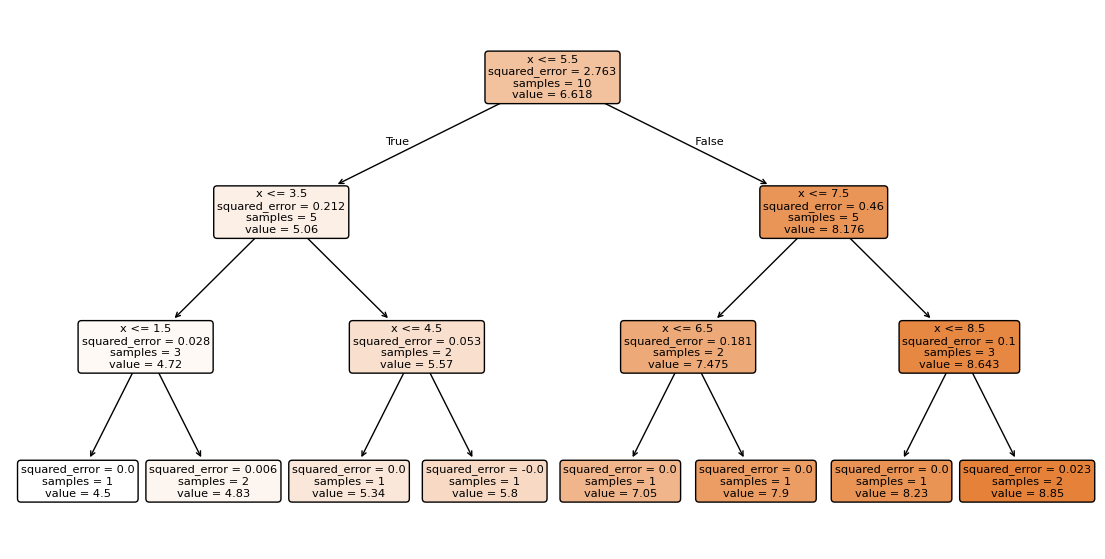

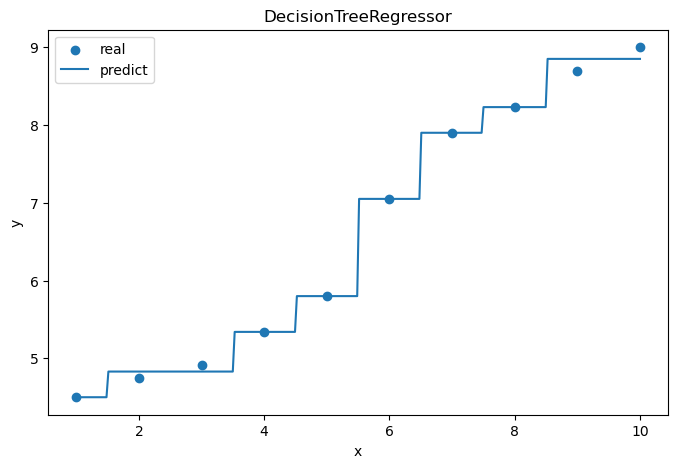

[0.00000000e+00 1.28000000e-03 4.50000000e-03 7.26000000e-03
 1.05800000e-02 2.56266667e-02 3.61250000e-02 8.67000000e-02
 1.63800333e-01 2.42736400e+00]
[2.84217094e-15 1.28000000e-03 5.78000000e-03 1.30400000e-02
 2.36200000e-02 4.92466667e-02 8.53716667e-02 1.72071667e-01
 3.35872000e-01 2.76323600e+00]
alpha=0.000000, mse=0.000000, leaves=10
alpha=0.001280, mse=0.001280, leaves=9
alpha=0.004500, mse=0.005780, leaves=8
alpha=0.007260, mse=0.013040, leaves=7
alpha=0.010580, mse=0.023620, leaves=6
alpha=0.025627, mse=0.049247, leaves=5
alpha=0.036125, mse=0.085372, leaves=4
alpha=0.086700, mse=0.172072, leaves=3
alpha=0.163800, mse=0.335872, leaves=2
alpha=2.427364, mse=2.763236, leaves=1


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import mean_squared_error, r2_score
# =========================
# 1. 数据
# =========================
X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8],
    [9],
    [10]
], dtype=float)
y = np.array([
    4.50,
    4.75,
    4.91,
    5.34,
    5.80,
    7.05,
    7.90,
    8.23,
    8.70,
    9.00
], dtype=float)

# =========================
# 2. 建立回归树
# =========================
reg = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=3,
    min_samples_leaf=1,
    random_state=0
)
reg.fit(X, y)


# =========================
# 3. 预测
# =========================

y_pred = reg.predict(X)
print("预测值：")
print(y_pred)
print("MSE：", mean_squared_error(y, y_pred))
print("R2：", r2_score(y, y_pred))

# =========================
# 4. 打印树规则
# =========================
rules = export_text(
    reg,
    feature_names=["x"]
)
print(rules)


# =========================
# 5. 可视化树
# =========================
plt.figure(figsize=(14, 7))
plot_tree(
    reg,
    feature_names=["x"],
    filled=True,
    rounded=True,
    impurity=True
)
plt.show()

# =========================
# 6. 画拟合曲线
# =========================
X_grid = np.linspace(1, 10, 300).reshape(-1, 1)
y_grid_pred = reg.predict(X_grid)
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="real")
plt.plot(X_grid, y_grid_pred, label="predict")
plt.xlabel("x")
plt.ylabel("y")
plt.title("DecisionTreeRegressor")
plt.legend()
plt.show()

reg0 = DecisionTreeRegressor(
    random_state=0,
    criterion="squared_error"
)
path = reg0.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas
impurities = path.impurities
print(ccp_alphas)
print(impurities)

regs = []
for alpha in ccp_alphas:
    reg = DecisionTreeRegressor(
        random_state=0,
        criterion="squared_error",
        ccp_alpha=alpha
    )
    reg.fit(X, y)
    regs.append(reg)
for alpha, reg in zip(ccp_alphas, regs):
    y_pred = reg.predict(X)
    mse = mean_squared_error(y, y_pred)
    print(f"alpha={alpha:.6f}, mse={mse:.6f}, leaves={reg.get_n_leaves()}")

#### 分类树

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(
    criterion = "gini",
    max_depth = 3,
    random_state = 0
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#### 回归树

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=3,
    random_state=0
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)